# Basic chatbot with langgraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function in the annotation defines how this state key should be updated
    # (in appends to the list rather than overwriting it)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [5]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="google_genai:gemini-flash-lite-latest")

In [6]:
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini Flash-Lite Latest', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-lite-latest', client=<google.genai.client.Client object at 0x000002215463FA10>, default_metadata=(), model_kwargs={})

In [7]:
# node functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

In [8]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()

In [9]:
response = graph.invoke({"messages": "Hello there gemini"})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [10]:
response["messages"][-1]

AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPB52CkGTvmuFsK1t1SGNeQ7q5NFvRplUrSCEbXz/5wMYOgvhRKbKa4iQhToRWHGLLf927k/sxeaT/rhRdaNGkZ3XEFpHBxTpmNy61DuWlCOd+ejLJ3NIw'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a08f9d-1b3c-7f62-b7b6-5b857f156338-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 9, 'total_tokens': 14, 'input_token_details': {'cache_read': 0}})

In [11]:
for event in graph.stream({"messages":"What is your name?"}):
    for value in event.values():
        print(value["messages"][-1].text)

I am a large language model, trained by Google.


# Tools

In [9]:
def multiply(a:int, b:int):
    """
    Multiple a and b
    args: 
     a (int) : first int
     b (int) : second int
    
    Returns :
    int : output int
    """
    return a*b

In [10]:
tools = [multiply]

llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini Flash-Lite Latest', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-lite-latest', client=<google.genai.client.Client object at 0x000002215463FA10>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description

In [15]:
response = llm_with_tools.invoke("What is 2 x 2?")
response

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 2, "a": 2}'}, '__gemini_function_call_thought_signatures__': {'call_5289019': 'El4KXAERTTIPv4bqg9A8wp9ZxjoqKxL/M/es4fKUDhjD0yooGTvg5RrEzBi/OZAg18nsEpOVdvrv2DvtZFtWwHDpao5boJpjhtyDgooaUKfNzYnPBI0HOL0blV7SDJ3s'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a08f9d-9759-7b41-a4c3-96277ec063bf-0', tool_calls=[{'name': 'multiply', 'args': {'b': 2, 'a': 2}, 'id': 'call_5289019', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 87, 'output_tokens': 16, 'total_tokens': 103, 'input_token_details': {'cache_read': 0}})

In [11]:
# stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Route to the tools when the latest model message contains a tool call;
# otherwise tools_condition routes to END.
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

### ReACT agent architecture

LLM -> Tools -> LLM, then LLM makes decision what to do next. This is called the ReAct agent architecture. 
Its based on: 
1. ACT
2. Observe
3. Reason

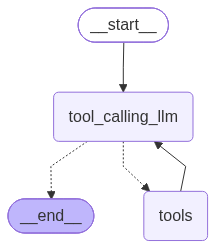

In [80]:
graph

In [77]:
response = graph.invoke({"messages": [("user", "What is 6 multiplied by 7?")]})

In [78]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 6 multiplied by 7?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_164672)
 Call ID: call_164672
  Args:
    b: 7
    a: 6
================================= Tool Message =================================
Name: multiply

42
================================== Ai Message ==================================

[{'type': 'text', 'text': '6 multiplied by 7 is 42.', 'extras': {'signature': 'El4KXAERTTIPy8AtjQhkF495C6o8crhtz//5j2TrMgEwXXw6JIWp+cHwuQNgC+gPJEWFS6zPG+Ej94KnAED9qUPtRFl+kZxHOZ7Pk5C0UFo9I8dK2csYcfGeV09kUx5n'}}]


# Adding Memory to Agent

In [17]:
response = graph.invoke({"messages":"Hello my name is Ajay"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ajay
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello Ajay! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPjNyyoVeXjhOSm1MphBxWIYyinceS1QC01r2XHhoK8uHYeeaOJD/37c0GXvXMR9sVs3mbex7w+F7vLOFYPoMew3b0d8bkmR1kvFWzPkPE8RQK04hx2Zdl'}}]


In [12]:
# stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Route to the tools when the latest model message contains a tool call;
# otherwise tools_condition routes to END.
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer=memory)

In [13]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages": "Hi my name is ajay"}, config=config)

In [14]:
response

{'messages': [HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='0f86a423-99f8-4c2a-9406-47bd14c3d4cb'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Ajay! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'El4KXAERTTIPFxEXypPYa1hsf5EMYbNgpHVA2Xxbb3AhLDX9cm+MF548H3KrpFQWoC08z9PX5omHd34xHbhNYeaP6ZsArDpCDSuq2OKvHQrgaZVdf4bBuOZz4ELTUzps'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a09488-9ce3-7ab0-8d34-81cd9102b88a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 18, 'total_tokens': 103, 'input_token_details': {'cache_read': 0}})]}

In [15]:
response = graph.invoke({"messages": "what is my name?"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='0f86a423-99f8-4c2a-9406-47bd14c3d4cb'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Ajay! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'El4KXAERTTIPFxEXypPYa1hsf5EMYbNgpHVA2Xxbb3AhLDX9cm+MF548H3KrpFQWoC08z9PX5omHd34xHbhNYeaP6ZsArDpCDSuq2OKvHQrgaZVdf4bBuOZz4ELTUzps'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a09488-9ce3-7ab0-8d34-81cd9102b88a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 18, 'total_tokens': 103, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='0fc3aeea-3cca-44a7-9ca7-668f155b0cbe'),
  AIMessage(content=[{'type': 'text', 'text': 'Your name is Ajay!', 'extras': {'sig

# Streaming

In [16]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [22]:
def superbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]}



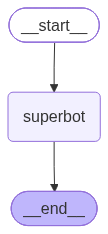

In [23]:
graph = StateGraph(State)

graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

graph_builder

### Streaming
There are two types of streaming methods: .stream() and .astream()
- both representing sync and async type of streaming

Additional parameters:
- values : This streams the full state of the graph after each node is called
- updates : This stream updates to the state graph after each node is called

In [26]:
config  = {"configurable" : {"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':"Hi my name is ajay and i like to repeat things"}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'Hi Ajay and I like to repeat things! \n\nWell, echo, echo, echo... what would you like to talk about today, Ajay and I like to repeat things? 😂', 'extras': {'signature': 'El4KXAERTTIPx478f2SBwNTK9cko1SLvKz6uUWWiZP9ho78r29eUj8FSTBMUpgIF2/xNLNU/zFcbWwmKjOXjE4sFm2sC17cahbj0dyXDyxpFScCvOfnkajMSGtISh2CD'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a094b8-6038-7112-81ff-3397212e252c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 92, 'output_tokens': 37, 'total_tokens': 129, 'input_token_details': {'cache_read': 0}})]}}


In [27]:
config  = {"configurable" : {"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':"Hi my name is ajay"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='5ed369a5-4d76-4ba5-957c-003ef231c539'), HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='215260c6-b760-4f61-8d97-d3eb11db84f6'), HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='3fe69604-35cb-45a0-9214-737d2b32a42a'), HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='8f222d59-05d4-448a-b58d-d33dd5bcc31b'), AIMessage(content=[{'type': 'text', 'text': 'Hi Ajay! It looks like your keyboard might have gotten stuck repeating your name. \n\nHow can I help you today, Ajay?', 'extras': {'signature': 'El4KXAERTTIP9nbmCzwgeE5m/+wSfk5Gyh5x37OAIAKNqvukiyBrc3s/vcP2LDfYYM2T2Znq8iq12nRjwGlYBXVjfJOjjUCd/gotUoIPaIZn1zUrpbYNq9AbEethRR4N'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_prov

In [30]:
config  = {"configurable" : {"thread_id":"3"}}
async for event in graph_builder.astream_events({'messages':"Hi my name is ajay"}, config=config, stream_mode="values"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is ajay'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a094bb-d8e4-7993-af4a-1bd395150028', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '01a094bb-d8e4-7993-af4a-1bd395150028', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi my name is ajay', additional_kwargs={}, response_metadata={}, id='aece78c0-3758-4764-8623-1530edfa8a91'), AIMessage(content=[{'type': 'text', 'text': "Hi Ajay! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'El4KXAERTTIPvxC+vdbBfMStXuxuooUYdY5jXThHLEltE0WBtO9rcEtL473ydXQ9grNT7AfGzyfUqKeHWjtYlme9N7LUNETDwHi0fPI20KqueYJBx6hkNhftoSbAQ/Uv'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'googl